In [1]:
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_curve, auc, roc_auc_score)
import warnings
warnings.filterwarnings('ignore')

In [2]:
import pandas as pd

In [3]:
df = pd.read_csv('BCDataset.csv')
print("Dataset shape:", df.shape)
print("\nClass distribution:\n", df['Status'].value_counts())


Dataset shape: (4024, 16)

Class distribution:
 Status
Alive    3408
Dead      616
Name: count, dtype: int64


In [4]:
print("\nMissing values:\n", df.isnull().sum().sum())
print("\nFeatures:\n", df.dtypes)


Missing values:
 4024

Features:
 Age                         int64
Race                          str
Marital Status                str
Unnamed: 3                float64
T Stage                       str
N Stage                       str
6th Stage                     str
Grade                         str
A Stage                       str
Tumor Size                  int64
Estrogen Status               str
Progesterone Status           str
Regional Node Examined      int64
Reginol Node Positive       int64
Survival Months             int64
Status                        str
dtype: object


Preprocessing

In [5]:
le = LabelEncoder()
df_copy = df.copy()
cols = df.select_dtypes(include='object').columns.tolist()
cols.remove('Status')
for col in cols:
    df_copy[col] = le.fit_transform(df_copy[col])
df_copy['Status'] = (df_copy['Status'] == 'Dead').astype(int)


# Set X and y and drop the null
X = df_copy.drop(['Status', 'Unnamed: 3'], axis=1)
y = df_copy['Status']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

Model 1: Logistic Regression

In [7]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_s, y_train)

lr_p = lr.predict(X_test_s)
lr_pp = lr.predict_proba(X_test_s)[:,1]
lr_as  = accuracy_score(y_test, lr_p)
lr_cvs  = cross_val_score(lr, X_train_s, y_train, cv=5, scoring='accuracy').mean()
lr_auc  = roc_auc_score(y_test, lr_pp)
print(f"Logistic Regression:\nAccuracy: {lr_as:.4f}\nCV: {lr_cvs:.4f}\nAUC: {lr_auc:.4f}")
print(classification_report(y_test, lr_p, target_names=['Alive','Dead']))

Logistic Regression:
Accuracy: 0.9006
CV: 0.8907
AUC: 0.8545
              precision    recall  f1-score   support

       Alive       0.91      0.98      0.94       682
        Dead       0.81      0.46      0.58       123

    accuracy                           0.90       805
   macro avg       0.86      0.72      0.76       805
weighted avg       0.89      0.90      0.89       805



Model 2: Random Forest

In [8]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

rf_p = rf.predict(X_test)
rf_pp = rf.predict_proba(X_test)[:,1]
rf_as  = accuracy_score(y_test, rf_p)
rf_cvs   = cross_val_score(rf, X_train, y_train, cv=5, scoring='accuracy').mean()
rf_auc  = roc_auc_score(y_test, rf_pp)
print(f"Random Forest:\nAcc: {rf_as:.4f}\nCV: {rf_cvs:.4f}\nAUC: {rf_auc:.4f}")
print(classification_report(y_test, rf_p, target_names=['Alive','Dead']))

Random Forest:
Acc: 0.9118
CV: 0.9006
AUC: 0.8264
              precision    recall  f1-score   support

       Alive       0.92      0.99      0.95       682
        Dead       0.87      0.50      0.63       123

    accuracy                           0.91       805
   macro avg       0.89      0.74      0.79       805
weighted avg       0.91      0.91      0.90       805



Figure 1

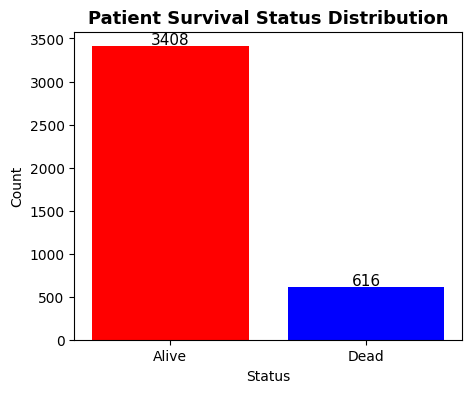

In [14]:
fig, ax = plt.subplots(figsize=(5,4))
vals = df['Status'].value_counts()

ax.bar(vals.index, vals.values, color=['#FF0000','#0000FF'])
ax.set_title('Patient Survival Status Distribution', fontsize=13, fontweight='bold')
ax.set_ylabel('Count')
ax.set_xlabel('Status')

for i, v in enumerate(vals.values):
    ax.text(i, v+20, str(v), ha='center', fontsize=11)

plt.show()

Figure 2

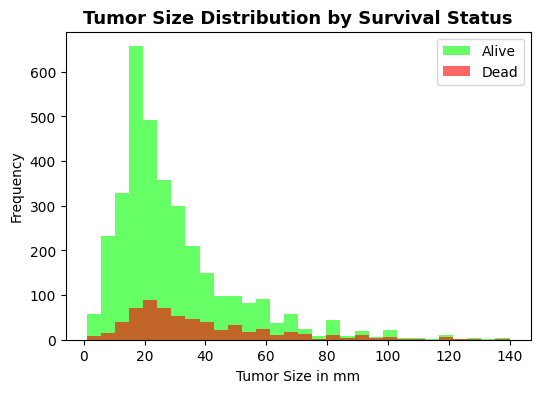

In [18]:
fig, ax = plt.subplots(figsize=(6,4))
palette = {'Alive': '#00FF00', 'Dead': '#FF0000'}

for status, color in palette.items():
    subset = df[df['Status']==status]['Tumor Size']
    ax.hist(subset, bins=30, alpha=0.6, label=status, color=color)

ax.set_title('Tumor Size Distribution by Survival Status', fontsize=13, fontweight='bold')
ax.set_xlabel('Tumor Size in mm'); ax.set_ylabel('Frequency'); ax.legend()
plt.show()

Figure 3

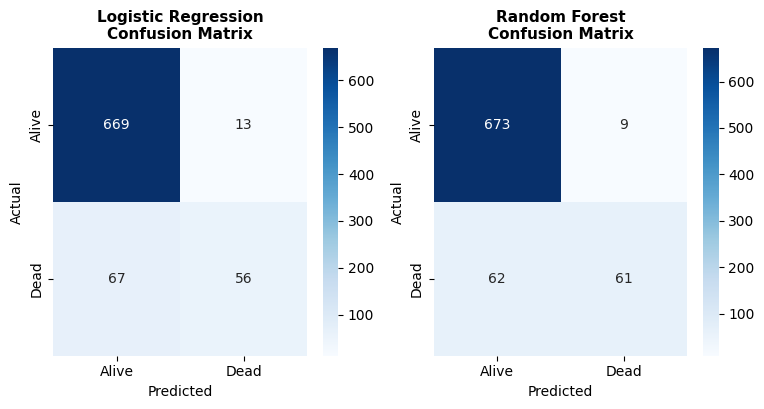

In [19]:
lr_p = lr.predict(X_test_s)
rf_p = rf.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(9,4))
for ax, pred, title in zip(axes,
    [lr_p, rf_p],
    ['Logistic Regression','Random Forest']):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Alive','Dead'], yticklabels=['Alive','Dead'])
    ax.set_title(f'{title}\nConfusion Matrix', fontsize=11, fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.show()

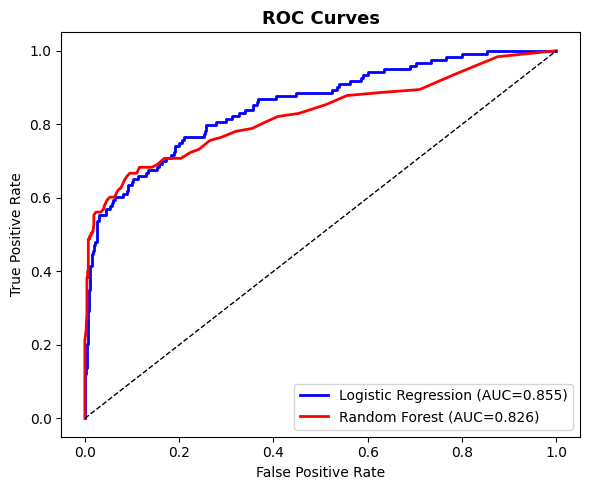

In [23]:
lr_prob = lr.predict_proba(X_test_s)[:,1]
rf_prob = rf.predict_proba(X_test)[:,1]

fig, ax = plt.subplots(figsize=(6,5))
for prob, label, color in [(lr_prob,'Logistic Regression','#0000FF'),
                            (rf_prob,'Random Forest','#FF0000')]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    ax.plot(fpr, tpr, color=color, lw=2,
            label=f'{label} (AUC={roc_auc_score(y_test,prob):.3f})')
ax.plot([0,1],[0,1],'k--', lw=1)
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves', fontsize=13, fontweight='bold')
ax.legend(); plt.tight_layout()
plt.show()